In [2]:
import sqlite3
from matplotlib import legend
import pandas as pd
import matplotlib.pyplot as plt 

In [6]:
#Hacemos la conexión con la base de datos
conn = sqlite3.connect("/Users/constanza/Documents/SQL con Dalto/northwind.db")

# 2. KPIs generales

## KPI 1: Ingresos totales

In [12]:
query1_kpi = '''SELECT sum(Price*quantity) as ingresos_totales FROM OrderDetails od
inner join Products p ON p.ProductID=od.ProductID'''

In [13]:
ingresos_totales = pd.read_sql_query(query1_kpi,conn)
print(ingresos_totales)

   ingresos_totales
0         386424.23


In [14]:
print(f"Ingresos totales: ${ingresos_totales.iloc[0,0]:,.2f}")

Ingresos totales: $386,424.23


## KPI 2: Cantidad de clientes

In [28]:
query2_kpi = '''SELECT count(customerID) AS cantidad_clientes FROM Customers'''

cantidad_clientes= pd.read_sql_query(query2_kpi,conn)


print(f"Clientes totales: {cantidad_clientes.iloc[0,0]}")

Clientes totales: 91


## KPI 3: Cantidad de productos

In [29]:
query3_kpi = '''SELECT count(productID) as cantidad_productos  FROM Products'''

cantidad_productos= pd.read_sql_query(query3_kpi,conn)


print(f"Productos totales: {cantidad_productos.iloc[0,0]}")

Productos totales: 77


## KPI 4: Cantidad de órdenes

In [30]:
query4_kpi = '''SELECT count(OrderID) as cantidad_ordenes  FROM orders'''

cantidad_ordenes= pd.read_sql_query(query4_kpi,conn)


print(f"Órdenes totales: {cantidad_ordenes.iloc[0,0]}")

Órdenes totales: 196


## KPI 5: Ticket promedio - ¿Cuánto genera una orden promedio?

In [31]:
query5_kpi = '''SELECT round(sum(price*Quantity)/count(DISTINCT O.OrderID)) as ticket_promedio FROM orders o
inner join OrderDetails od ON od.OrderID=o.OrderID
inner join Products p ON od.ProductID=p.ProductID'''

ticket_promedio= pd.read_sql_query(query5_kpi,conn)


print(f"Ticket promedio: {ticket_promedio.iloc[0,0]}")

Ticket promedio: 1972.0


In [32]:
print("KPI generales:\n"
f"Ingresos totales: ${ingresos_totales.iloc[0,0]:,.2f}\n"
f"Clientes totales: {cantidad_clientes.iloc[0,0]}\n"
f"Productos totales: {cantidad_productos.iloc[0,0]}\n"
f"Órdenes totales: {cantidad_ordenes.iloc[0,0]}\n"
f"Ticket promedio: {ticket_promedio.iloc[0,0]}")

KPI generales:
Ingresos totales: $386,424.23
Clientes totales: 91
Productos totales: 77
Órdenes totales: 196
Ticket promedio: 1972.0


Los KPIs muestran una visión general del negocio:
volumen de clientes, productos, órdenes e ingresos generados.

# 3. Análisis por Categoría

### Grafico de ingresos por categoría

In [ ]:
query1_cat = ''' 
SELECT CategoryName, count(p.productID) as cantidad_productos,sum(Price*quantity) as ingresos FROM Categories c
inner join Products p ON c.CategoryID=p.CategoryID
inner join OrderDetails od ON p.ProductID=od.ProductID
GROUP by c.CategoryID
order by ingresos
'''

In [ ]:
ingresos_por_categoria = pd.read_sql_query(query1_cat,conn)
print(ingresos_por_categoria)

     CategoryName  cantidad_productos  ingresos
0  Grains/Cereals                  42  22327.75
1         Produce                  33  23401.40
2         Seafood                  67  29652.30
3      Condiments                  49  35071.60
4    Meat/Poultry                  50  51676.52
5     Confections                  84  54909.16
6  Dairy Products                 100  69921.00
7       Beverages                  93  99464.50


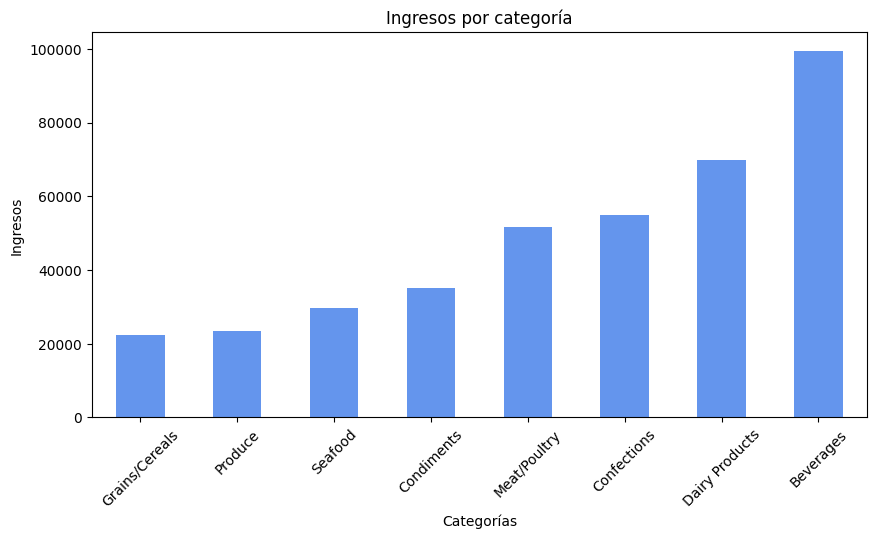

In [23]:
ingresos_por_categoria.plot(x="CategoryName", y="ingresos", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Ingresos por categoría")
plt.xlabel("Categorías")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.show()

La categoría Beverages genera los mayores ingresos. En contraste, categorías como Produce y Grains/Cereals generan menores ingresos.

### Unidades vendidas por categoría

In [33]:
query2_cat = '''SELECT CategoryName, sum(quantity) as unidades_vendidas FROM Categories c
inner join Products p ON c.CategoryID=p.CategoryID
inner join OrderDetails od ON p.ProductID=od.ProductID
GROUP by c.CategoryID
order by unidades_vendidas DESC'''

unidades_por_categoria = pd.read_sql_query(query2_cat,conn)
print(unidades_por_categoria)

     CategoryName  unidades_vendidas
0  Dairy Products               2601
1       Beverages               2289
2     Confections               2110
3         Seafood               1445
4      Condiments               1383
5    Meat/Poultry               1288
6  Grains/Cereals                912
7         Produce                715


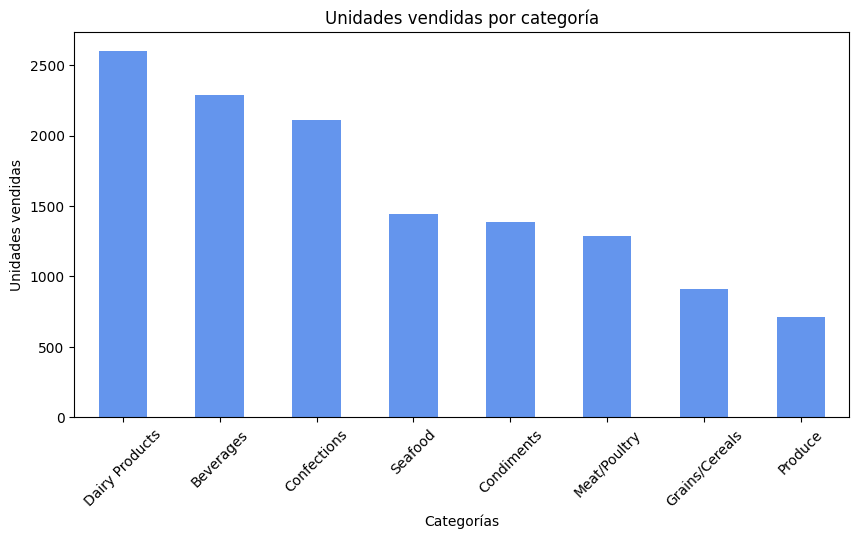

In [34]:
unidades_por_categoria.plot(x="CategoryName", y="unidades_vendidas", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Unidades vendidas por categoría")
plt.xlabel("Categorías")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.show()

Dairy Products es la categoría con mayor cantidad de unidades vendidas.
Existe una diferencia considerable entre las categorías más y menos vendidas.
Un mayor volumen de ventas no necesariamente implica mayores ingresos.

### Precio promedio por categoría

In [36]:
query3_cat = '''SELECT CategoryName, round(avg(price)) as precio_promedio FROM Categories c
inner join Products p ON c.CategoryID=p.CategoryID
inner join OrderDetails od ON p.ProductID=od.ProductID
group by c.CategoryID
order by precio_promedio'''

precio_promedio_por_categoria = pd.read_sql_query(query3_cat,conn)
print(precio_promedio_por_categoria)

     CategoryName  precio_promedio
0         Seafood             20.0
1      Condiments             23.0
2  Grains/Cereals             24.0
3     Confections             26.0
4  Dairy Products             29.0
5         Produce             33.0
6       Beverages             35.0
7    Meat/Poultry             45.0


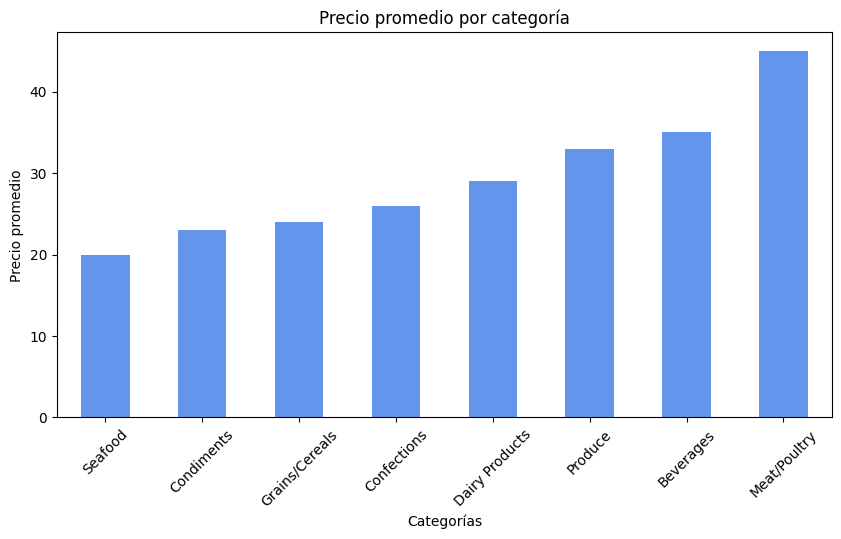

In [37]:
precio_promedio_por_categoria.plot(x="CategoryName", y="precio_promedio", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Precio promedio por categoría")
plt.xlabel("Categorías")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

Meat/Poultry presenta el precio promedio más elevado. Las categorías con precios más altos no siempre son las que generan más ingresos.

## Conclusión general de categorías:

El análisis por categoría muestra que los ingresos dependen tanto del volumen de ventas como del precio de los productos. Mientras que Dairy Products lidera en unidades vendidas, Beverages genera los mayores ingresos. Por otro lado, categorías como Meat/Poultry presentan precios promedio elevados, aunque no necesariamente lideran las ventas. Esto sugiere que distintas categorías contribuyen al negocio mediante estrategias diferentes: algunas por volumen y otras por valor.

# 4. Análisis por producto

### Ingresos por producto

In [ ]:
query1_producto = ''' SELECT ProductName, sum(quantity *Price) as ingresos FROM Products p
inner join OrderDetails od ON p.ProductID=od.ProductID
group by p.ProductID
order by ingresos DESC
LIMIT 10
'''

In [45]:
productos_por_categoria = pd.read_sql_query(query1_producto,conn)
print(productos_por_categoria)

               ProductName  ingresos
0            Côte de Blaye  62976.50
1  Thüringer Rostbratwurst  20796.72
2     Raclette Courdavault  19030.00
3           Tarte au sucre  16022.50
4        Camembert Pierrot  14620.00
5             Alice Mutton  12909.00
6   Gnocchi di nonna Alice  10222.00
7   Mozzarella di Giovanni   9396.00
8             Vegie-spread   9175.10
9    Manjimup Dried Apples   8639.00


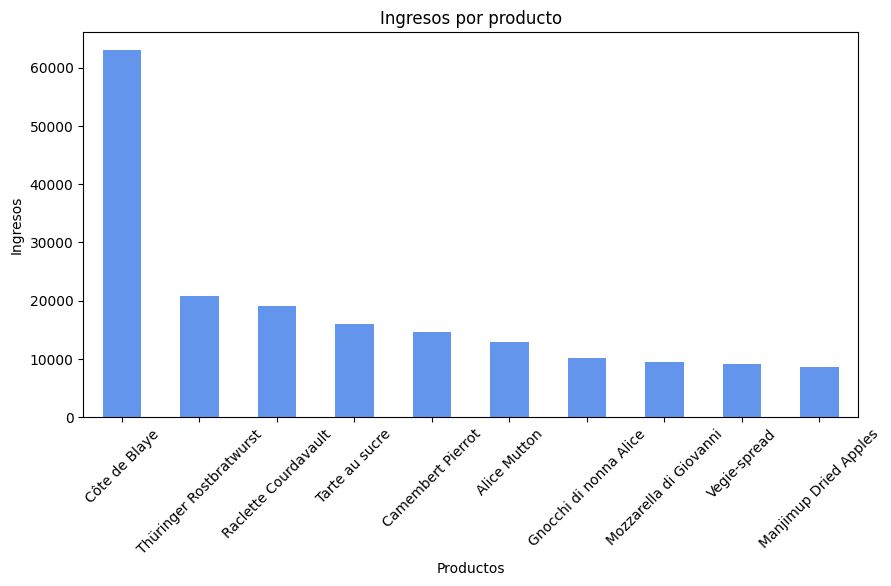

In [46]:
productos_por_categoria.plot(x="ProductName", y="ingresos", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Ingresos por producto")
plt.xlabel("Productos")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.show()

La distribución de ingresos por producto es altamente asimétrica, con Côte de Blaye dominando claramente el ranking. La caída abrupta hacia los siguientes productos evidencia una fuerte concentración de ingresos en pocos ítems

### Productos más vendidos

In [ ]:
query2_producto = '''SELECT ProductName, sum(quantity) as total_vendidos FROM Products p
inner join OrderDetails od ON p.ProductID=od.ProductID
GROUP by p.ProductID
order by total_vendidos DESC
LIMIT 10 '''

productos_mas_vendidos = pd.read_sql_query(query2_producto,conn)
print(productos_mas_vendidos)


            ProductName  total_vendidos
0     Gorgonzola Telino             458
1     Camembert Pierrot             430
2        Steeleye Stout             369
3  Raclette Courdavault             346
4                 Chang             341
5               Pavlova             338
6           Fløtemysost             336
7          Alice Mutton             331
8        Tarte au sucre             325
9               Geitost             316


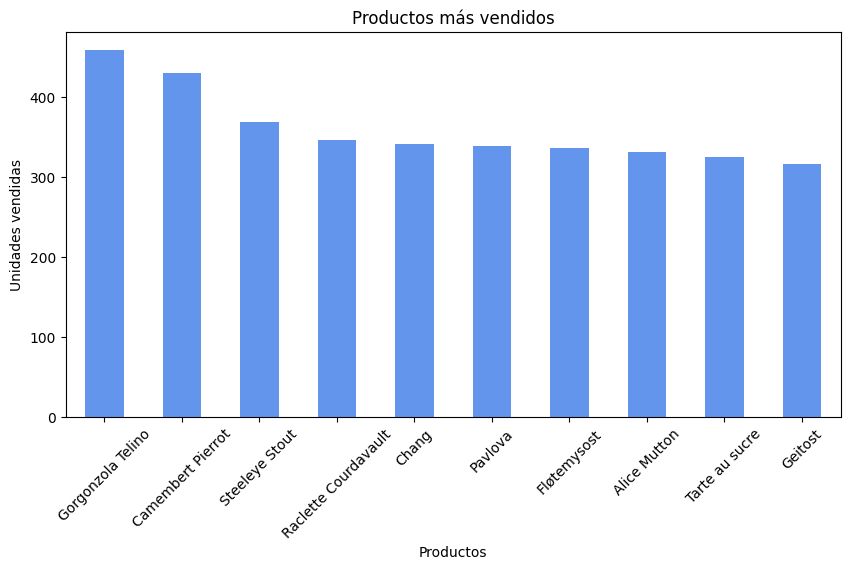

In [48]:
productos_mas_vendidos.plot(x="ProductName", y="total_vendidos", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Productos más vendidos")
plt.xlabel("Productos")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.show()

El producto más vendido no coincide con el de mayores ingresos. Los ingresos dependen tanto del volumen vendido como del precio.

### Análisis de precios vs ventas

In [65]:
query3_producto= '''SELECT
    ProductName,
    Price,
    SUM(Quantity) AS unidades_vendidas
FROM Products p
INNER JOIN OrderDetails od
    ON p.ProductID = od.ProductID
GROUP BY p.ProductID'''

precios_vs_ventas = pd.read_sql_query(query3_producto,conn)
print(precios_vs_ventas)

                        ProductName  Price  unidades_vendidas
0                             Chais  18.00                159
1                             Chang  19.00                341
2                     Aniseed Syrup  10.00                 80
3      Chef Anton's Cajun Seasoning  22.00                107
4            Chef Anton's Gumbo Mix  21.35                129
..                              ...    ...                ...
72                       Röd Kaviar  15.00                 45
73                    Longlife Tofu  10.00                186
74             Rhönbräu Klosterbier   7.75                144
75                     Lakkalikööri  18.00                198
76  Original Frankfurter grüne Soße  13.00                108

[77 rows x 3 columns]


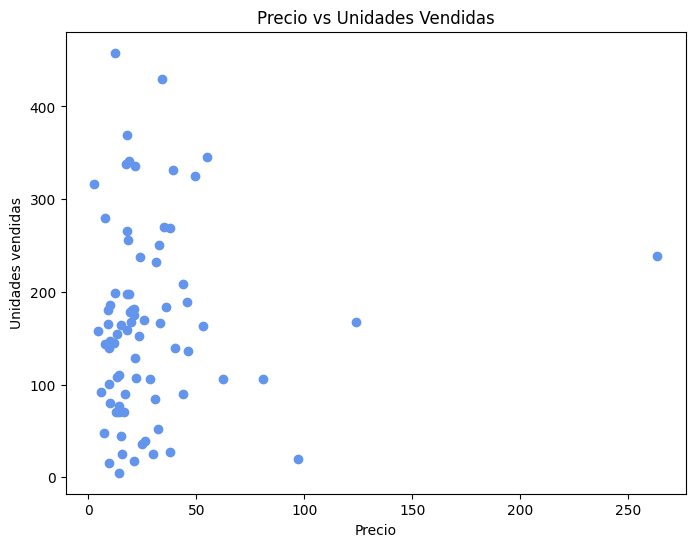

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(x="Price", y="unidades_vendidas", data=precios_vs_ventas, color="cornflowerblue")

plt.xlabel("Precio")
plt.ylabel("Unidades vendidas")
plt.title("Precio vs Unidades Vendidas")

plt.show()

No se observa una relación lineal clara entre el precio de los productos y las unidades vendidas. Existen productos de bajo precio con altos niveles de ventas, pero también productos económicos con baja demanda. Asimismo, algunos productos de precio elevado mantienen volúmenes de venta relativamente altos. El precio por sí solo no parece explicar el volumen de ventas de los productos. Esto sugiere que otros factores, como la demanda, la categoría del producto o las preferencias de los clientes, podrían influir en las ventas.

## Conclusiones generales de productos: 
El análisis por producto mostró que los productos que generan mayores ingresos no son necesariamente los más vendidos. Esto evidencia que la facturación depende tanto del volumen de ventas como del precio de los productos. Además, se observó que no existe una relación clara entre el precio y las unidades vendidas, lo que sugiere que otros factores además del precio influyen en la demanda.

# 5.Análisis por cliente

### 10 mejores clientes

In [53]:
query1_cliente = '''SELECT CustomerName, sum(Price*quantity) as ingresos FROM Customers c
inner join Orders o ON c.CustomerID=o.CustomerID
inner join OrderDetails od ON od.OrderID=o.OrderID
inner join Products p ON od.ProductID=p.ProductID
group by c.CustomerID
order by ingresos DESC
LIMIT 10 '''


In [54]:
mejores_10_clientes = pd.read_sql_query(query1_cliente,conn)
print(mejores_10_clientes)

                   CustomerName  ingresos
0                  Ernst Handel  35631.21
1                Mère Paillarde  23362.60
2            Save-a-lot Markets  22500.06
3    Rattlesnake Canyon Grocery  18421.42
4                    QUICK-Stop  18178.80
5                 Queen Cozinha  17880.60
6              Piccolo und mehr  16040.75
7  Hungry Owl All-Night Grocers  15391.02
8          Blondel père et fils  15253.75
9                 Simons bistro  14619.00


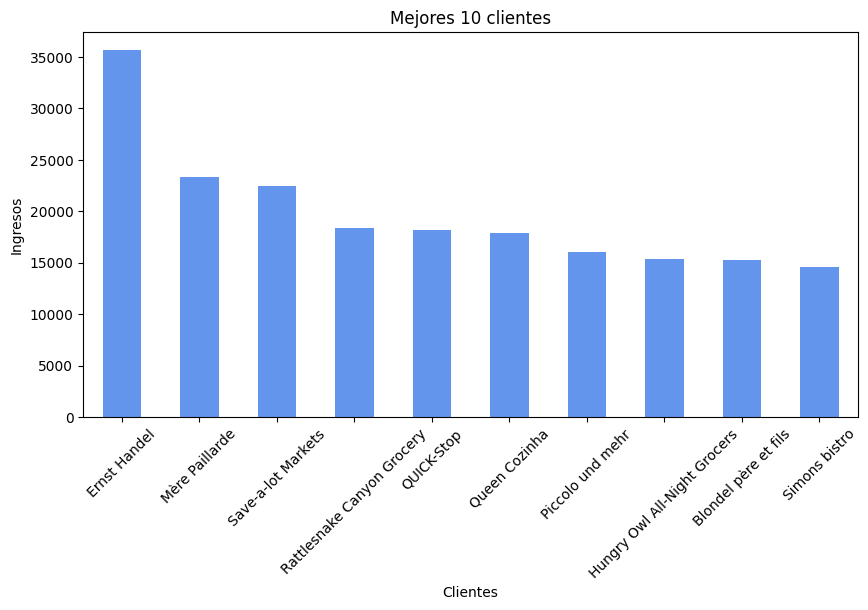

In [55]:
mejores_10_clientes.plot(x="CustomerName", y="ingresos", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Mejores 10 clientes")
plt.xlabel("Clientes")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.show()

Ernst Handel se posiciona como el cliente más valioso para la empresa, dado que aporta la mayor cantidad de ingresos entre todos los clientes analizados.

### ¿Qué porcentaje de los ingresos generan?

In [57]:
query2_cliente = '''SELECT sum(Price*quantity) as ingresos_totales FROM Customers c
inner join Orders o ON c.CustomerID=o.CustomerID
inner join OrderDetails od ON od.OrderID=o.OrderID
inner join Products p ON od.ProductID=p.ProductID'''

ingresos_totales = pd.read_sql_query(query2_cliente,conn)
print(ingresos_totales)

   ingresos_totales
0         386424.23


In [59]:
mejores_10_clientes["participacion"] = (
    mejores_10_clientes["ingresos"] /
    ingresos_totales.iloc[0,0]
) * 100
print(mejores_10_clientes)

                   CustomerName  ingresos  participacion
0                  Ernst Handel  35631.21       9.220749
1                Mère Paillarde  23362.60       6.045842
2            Save-a-lot Markets  22500.06       5.822632
3    Rattlesnake Canyon Grocery  18421.42       4.767149
4                    QUICK-Stop  18178.80       4.704363
5                 Queen Cozinha  17880.60       4.627194
6              Piccolo und mehr  16040.75       4.151073
7  Hungry Owl All-Night Grocers  15391.02       3.982933
8          Blondel père et fils  15253.75       3.947410
9                 Simons bistro  14619.00       3.783148


In [60]:
mejores_10_clientes["participacion"].sum()

np.float64(51.052494818971375)

In [61]:
cantidad_clientes.iloc[0,0]

np.int64(91)

Los 10 principales clientes representan el 51% de los ingresos totales de la empresa. Considerando que la empresa cuenta con 91 clientes, esto significa que aproximadamente el 11% de los clientes genera más de la mitad de la facturación, evidenciando una fuerte concentración de ingresos.

## Conclusiones generales de clientes: 
El análisis de clientes evidenció una fuerte concentración de los ingresos en un grupo reducido de clientes. Los 10 principales clientes generan aproximadamente el 51% de la facturación total de la empresa, lo que indica que la retención y fidelización de estos clientes resulta fundamental para el negocio. Asimismo, Ernst Handel se posiciona como el cliente de mayor valor al aportar la mayor cantidad de ingresos entre todos los clientes analizados.

# 6. Análisis por Empleado

### Top 10 empleados que generan más ingresos

In [62]:
query1_empleados = '''SELECT FirstName || ' ' || LastName AS Empleado, sum(Price*quantity) as ingresos  FROM Employees e
inner join Orders o ON e.EmployeeID=o.EmployeeID
inner join OrderDetails od ON od.OrderID=o.OrderID
inner join Products p ON od.ProductID=p.ProductID
group by e.EmployeeID
order by ingresos DESC
LIMIT 10'''

mejores_10_empleados = pd.read_sql_query(query1_empleados,conn)
print(mejores_10_empleados)

           Empleado   ingresos
0  Margaret Peacock  105696.50
1     Nancy Davolio   57690.39
2   Janet Leverling   42838.35
3       Robert King   39772.30
4    Laura Callahan   39309.38
5     Andrew Fuller   32503.16
6   Steven Buchanan   27480.80
7    Michael Suyama   25399.25
8    Anne Dodsworth   15734.10


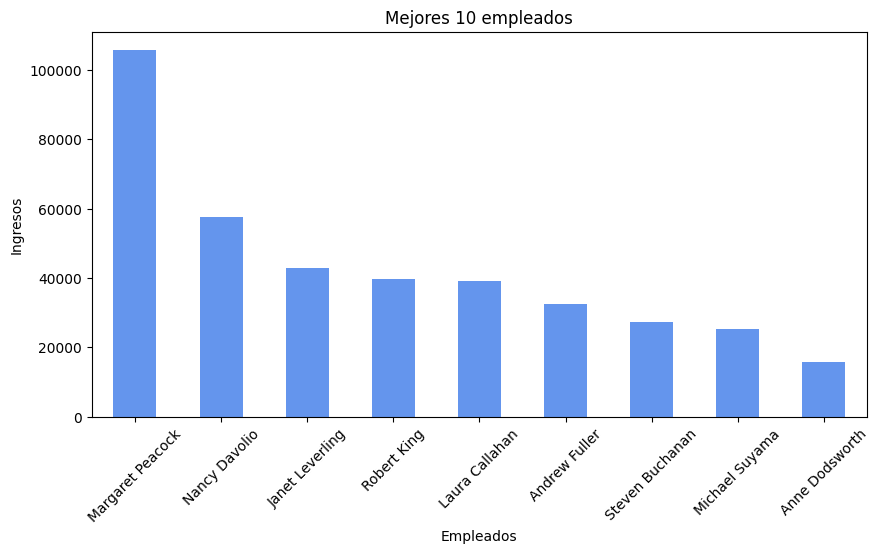

In [11]:
mejores_10_empleados.plot(x="Empleado", y="ingresos", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Mejores 10 empleados")
plt.xlabel("Empleados")
plt.ylabel("Ingresos")
plt.xticks(rotation=45)
plt.show()

Margaret Peacock se posicionó como la empleada con mayores ingresos generados, al registrar el mayor volumen de ventas entre todos los empleados analizados.

### Empleados que procesan más órdenes.

In [63]:
query2_empleados = '''SELECT FirstName || ' ' || LastName AS Empleado, count(OrderID) as ordenes_procesadas  FROM Employees e
inner join Orders o ON e.EmployeeID=o.EmployeeID
group by e.EmployeeID
order by ordenes_procesadas DESC'''

ordenes_por_empleado = pd.read_sql_query(query2_empleados,conn)
print(ordenes_por_empleado)

           Empleado  ordenes_procesadas
0  Margaret Peacock                  40
1   Janet Leverling                  31
2     Nancy Davolio                  29
3    Laura Callahan                  27
4     Andrew Fuller                  20
5    Michael Suyama                  18
6       Robert King                  14
7   Steven Buchanan                  11
8    Anne Dodsworth                   6


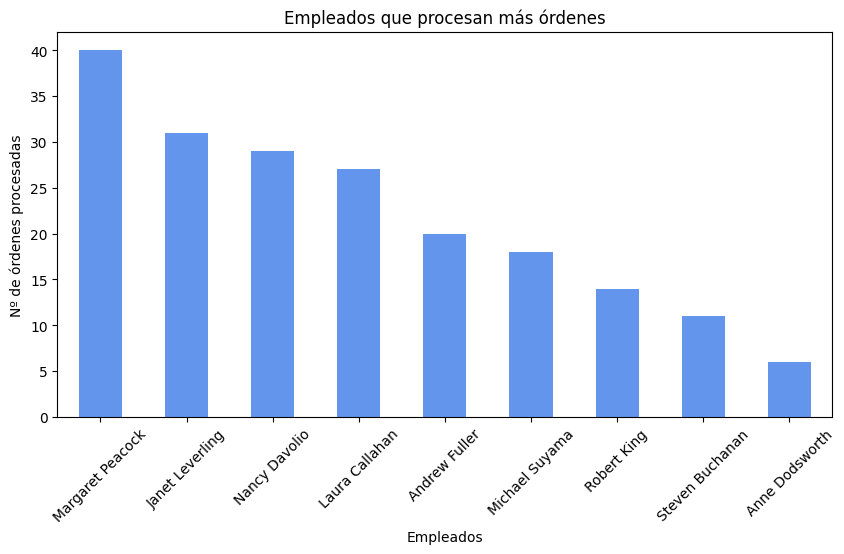

In [64]:
ordenes_por_empleado.plot(x="Empleado", y="ordenes_procesadas", kind="bar",figsize=(10,5), legend=False, color="cornflowerblue")


plt.title("Empleados que procesan más órdenes")
plt.xlabel("Empleados")
plt.ylabel("Nº de órdenes procesadas")
plt.xticks(rotation=45)
plt.show()

Margaret Peacock se destaca como la empleada con mejor desempeño general, ya que lidera tanto el ranking de ingresos generados como el de órdenes procesadas. Sin embargo, la relación entre cantidad de órdenes e ingresos no es completamente proporcional para el resto de los empleados. Nancy Davolio ocupa el segundo lugar en ingresos generados, aunque procesa menos órdenes que Janet Leverling. Esto indica que el valor promedio de las ventas realizadas por Nancy es superior.

## Conclusiones generales de empleados:

El desempeño de los empleados no depende únicamente de la cantidad de órdenes procesadas. Si bien existe una relación positiva entre ambas variables, algunos vendedores generan mayores ingresos con un menor número de órdenes, lo que evidencia diferencias en el valor promedio de las ventas realizadas.

# 7. Análisis temporal

### Ingresos por mes

In [69]:
query1_mensual = '''SELECT
    strftime('%Y-%m', OrderDate) AS mes,
    SUM(p.Price * od.Quantity) AS ingresos
FROM Orders o
INNER JOIN OrderDetails od
    ON o.OrderID = od.OrderID
INNER JOIN Products p
    ON od.ProductID = p.ProductID
GROUP BY mes
ORDER BY mes'''

ventas_mensuales = pd.read_sql_query(query1_mensual, conn)

print(ventas_mensuales)

       mes  ingresos
0  1996-07  37779.85
1  1996-08  33285.49
2  1996-09  34565.60
3  1996-10  51528.69
4  1996-11  62163.99
5  1996-12  63721.23
6  1997-01  83400.47
7  1997-02  19978.91


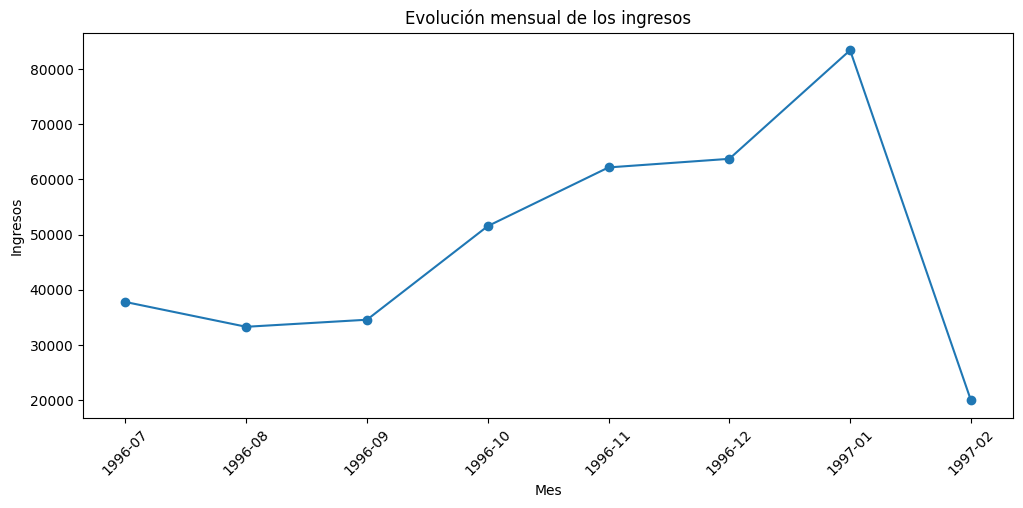

In [70]:
plt.figure(figsize=(12,5))

plt.plot(
    ventas_mensuales["mes"],
    ventas_mensuales["ingresos"],
    marker="o"
)

plt.title("Evolución mensual de los ingresos")
plt.xlabel("Mes")
plt.ylabel("Ingresos")

plt.xticks(rotation=45)

plt.show()

Se observa una tendencia creciente en los ingresos mensuales entre julio de 1996 y enero de 1997, alcanzando un máximo en enero de 1997. Esto podría indicar una expansión de la actividad comercial o una mayor demanda durante esos meses. Posteriormente se registra una caída pronunciada en febrero de 1997. Sin embargo, este descenso debe interpretarse con cautela, ya que podría deberse a que los datos disponibles para ese mes son parciales y no representan el período completo.